# Emotion Recognition in Vietnamese Social Media (UIT-VSMEC)

**Task 2 - Deep Learning Final Project**  
Ton Duc Thang University - Faculty of Information Technology  

**Team:**  
- Nguyen Tran Nhat An - 523H0115  
- Chung Quang Vu - 523H0196  
- Nguyen Nhat Chieu - 522H0133  

**Dataset:** [tridm/UIT-VSMEC](https://huggingface.co/datasets/tridm/UIT-VSMEC)  
**Emotion Labels (7):** Enjoyment, Sadness, Anger, Disgust, Fear, Surprise, Other

##  0. Setup

In [1]:
!pip install transformers datasets tokenizers accelerate scikit-learn pandas numpy matplotlib seaborn huggingface_hub tqdm gradio -q


## 1. Imports & Config

In [2]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
CFG = {
    'model_name': 'vinai/phobert-base-v2',
    'max_len': 128,
    'dropout': 0.3,
    'labels': ['Enjoyment', 'Sadness', 'Anger', 'Disgust', 'Fear', 'Surprise', 'Other'],
    'num_labels': 7,
    'epochs': 10,
    'batch_size': 16,
    'lr': 2e-5,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0,
    'output_dir': './checkpoints',
    'best_model_path': './checkpoints/best_model.pt',
    'hf_repo': 'RudiChill/vismec-emotion',
    'push_to_hub': True,
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Config loaded.')

Config loaded.


## 2. Dataset

Load **UIT-VSMEC** directly from HuggingFace. Dataset gồm ~6,927 câu tiếng Việt từ mạng xã hội, được gán nhãn 7 cảm xúc (single-label).

In [4]:
from datasets import load_dataset

raw = load_dataset('tridm/UIT-VSMEC')
print(raw)

# Build label -> index mapping
label2id = {l: i for i, l in enumerate(CFG['labels'])}
id2label  = {i: l for l, i in label2id.items()}
print('Label mapping:', label2id)

def hf_to_df(split):
    rows = [{'text': r['Sentence'], 'label': label2id[r['Emotion']]} for r in raw[split]]
    return pd.DataFrame(rows)

train_df = hf_to_df('train')
val_df   = hf_to_df('validation')
test_df  = hf_to_df('test')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
train_df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5548 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/693 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 5548
    })
    validation: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 686
    })
    test: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 693
    })
})
Label mapping: {'Enjoyment': 0, 'Sadness': 1, 'Anger': 2, 'Disgust': 3, 'Fear': 4, 'Surprise': 5, 'Other': 6}
Train: 5548 | Val: 686 | Test: 693


,text,label
0,cho mình xin bài nhạc tên là gì với ạ,6
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,3
2,lo học đi . yêu đương lol gì hay lại thích học...,3


## 3. EDA

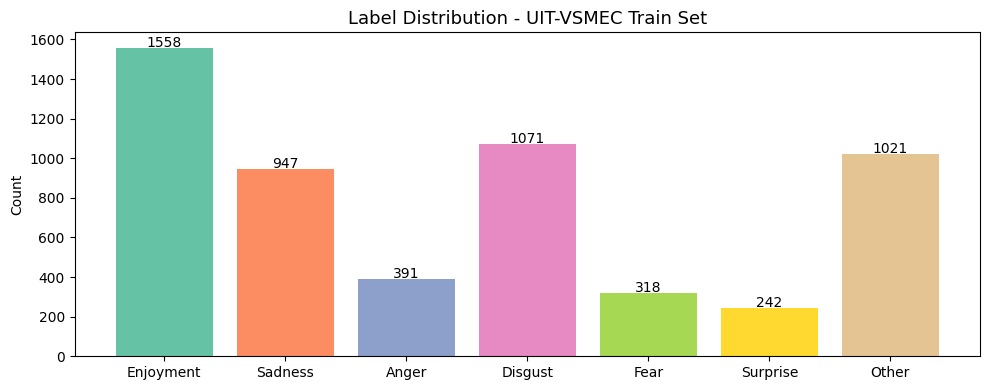

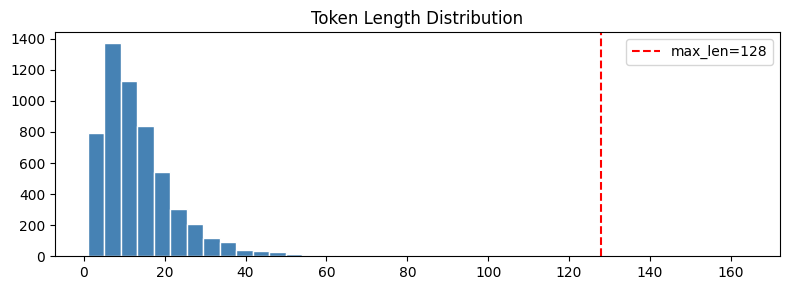

count    5548.000000
mean       14.008291
std        10.438689
min         1.000000
25%         7.000000
50%        12.000000
75%        18.000000
max       164.000000
Name: len, dtype: float64


In [5]:
# Label distribution
counts = train_df['label'].value_counts().sort_index()
colors = plt.cm.Set2.colors
plt.figure(figsize=(10,4))
bars = plt.bar(CFG['labels'], counts, color=colors)
for bar, c in zip(bars, counts):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(int(c)), ha='center', fontsize=10)
plt.title('Label Distribution - UIT-VSMEC Train Set', fontsize=13)
plt.ylabel('Count'); plt.tight_layout()
plt.savefig('label_dist.png', dpi=120); plt.show()

# Text length distribution
train_df['len'] = train_df['text'].str.split().str.len()
plt.figure(figsize=(8,3))
plt.hist(train_df['len'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(CFG['max_len'], color='red', linestyle='--', label=f'max_len={CFG["max_len"]}')
plt.title('Token Length Distribution'); plt.legend(); plt.tight_layout()
plt.savefig('len_dist.png', dpi=120); plt.show()
print(train_df['len'].describe())

## 4. Dataset Class & DataLoaders

In [6]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print('Tokenizer loaded, vocab size:', tokenizer.vocab_size)

class VSMECDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        text  = str(self.df.loc[idx, 'text'])
        label = int(self.df.loc[idx, 'label'])
        enc = self.tok(text, max_length=self.max_len, padding='max_length',
                       truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long)
        }

train_ds = VSMECDataset(train_df, tokenizer, CFG['max_len'])
val_ds   = VSMECDataset(val_df,   tokenizer, CFG['max_len'])
test_ds  = VSMECDataset(test_df,  tokenizer, CFG['max_len'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

b = next(iter(train_loader))
print(f'Batch input_ids: {b["input_ids"].shape}, labels: {b["labels"].shape}')

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded, vocab size: 64000
Batch input_ids: torch.Size([16, 128]), labels: torch.Size([16])


## 5. Model Architecture

In [7]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, h // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h // 2, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)

model = PhoBERTClassifier(CFG['model_name'], CFG['num_labels'], CFG['dropout']).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total:,} | Trainable: {trainable:,}')

with torch.no_grad():
    out = model(b['input_ids'].to(DEVICE), b['attention_mask'].to(DEVICE))
print(f'Output shape: {out.shape}')  # (batch, 7)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 135,296,263 | Trainable: 135,296,263
Output shape: torch.Size([16, 7])


## 5b. Load Checkpoint từ HuggingFace Hub *(Bỏ qua Section 6 nếu dùng cell này)*

Nếu đã có model trained trên HF Hub, chạy cell này để load thẳng và **skip toàn bộ bước training**.

*(Lưu ý: Cell này cũng định nghĩa sẵn các hàm `evaluate` và `criterion` cần thiết cho Section 7)*

In [8]:
# --- 1. Định nghĩa criterion & evaluate (BẮT BUỘC CHẠY DÙ CÓ SKIP TRAINING HAY KHÔNG) ---
criterion = nn.CrossEntropyLoss()

def compute_metrics(y_true, y_pred):
    return {
        'accuracy':    accuracy_score(y_true, y_pred),
        'f1_macro':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

@torch.no_grad()
def evaluate(model, loader, crit, device):
    model.eval()
    total_loss, all_true, all_pred = 0.0, [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        logits = model(ids, mask)
        total_loss += crit(logits, labs).item()
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_pred.extend(preds); all_true.extend(labs.cpu().numpy())
    return total_loss / len(loader), compute_metrics(all_true, all_pred)

print('✅ Đã định nghĩa criterion và evaluate.')


✅ Đã định nghĩa criterion và evaluate.


In [9]:
# --- 2. Load Checkpoint từ HuggingFace Hub ---
from huggingface_hub import hf_hub_download
import shutil

HF_REPO = 'RudiChill/vismec-emotion'  # ← đổi thành HF repo của bạn

os.makedirs(CFG['output_dir'], exist_ok=True)
ckpt_path = hf_hub_download(
    repo_id=HF_REPO,
    filename='classifier_head.pt',
    local_dir=CFG['output_dir'],
    local_dir_use_symlinks=False
)
shutil.copy(ckpt_path, CFG['best_model_path'])

model.load_state_dict(torch.load(CFG['best_model_path'], map_location=DEVICE, weights_only=False))
model.eval()
print(f'✅ Loaded checkpoint from {HF_REPO} — skip training, go to Section 7!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


classifier_head.pt:   0%|          | 0.00/541M [00:00<?, ?B/s]

✅ Loaded checkpoint from RudiChill/vismec-emotion — skip training, go to Section 7!


## 6. Training *(Bỏ qua nếu đã chạy Section 5b)*

Dùng **CrossEntropyLoss** vì đây là bài toán single-label classification.

In [ ]:
optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
total_steps  = len(train_loader) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

Total steps: 3470 | Warmup: 347


In [ ]:
def train_epoch(model, loader, opt, sched, crit, device):
    model.train()
    total_loss, all_true, all_pred = 0.0, [], []
    for batch in tqdm(loader, desc='Train', leave=False):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        opt.zero_grad()
        logits = model(ids, mask)
        loss = crit(logits, labs)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
        opt.step(); sched.step()
        total_loss += loss.item()
        preds = logits.argmax(dim=-1).detach().cpu().numpy()
        all_pred.extend(preds); all_true.extend(labs.cpu().numpy())
    return total_loss / len(loader), compute_metrics(all_true, all_pred)

In [ ]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_f1':[], 'val_f1':[]}
best_val_f1 = 0.0

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_m = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    vl_loss, vl_m = evaluate(model, val_loader, criterion, DEVICE)
    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_m['accuracy']); history['val_acc'].append(vl_m['accuracy'])
    history['train_f1'].append(tr_m['f1_macro']); history['val_f1'].append(vl_m['f1_macro'])
    print(f"Epoch {epoch:02d}/{CFG['epochs']} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_m['accuracy']:.4f} F1: {tr_m['f1_macro']:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_m['accuracy']:.4f} F1: {vl_m['f1_macro']:.4f}")
    if vl_m['f1_macro'] > best_val_f1:
        best_val_f1 = vl_m['f1_macro']
        torch.save(model.state_dict(), CFG['best_model_path'])
        print(f'  >> Best model saved (Val F1: {best_val_f1:.4f})')

print(f'Training done. Best Val F1-macro: {best_val_f1:.4f}')

Train:   0%|          | 0/347 [00:00<?, ?it/s]

Eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.3194 Acc: 0.9212 F1: 0.8976 | Val Loss: 1.6068 Acc: 0.6064 F1: 0.5365
  >> Best model saved (Val F1: 0.5365)


Train:   0%|          | 0/347 [00:00<?, ?it/s]

Eval:   0%|          | 0/43 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.0843 Acc: 0.9832 F1: 0.9772 | Val Loss: 2.3177 Acc: 0.6181 F1: 0.5672


Train:   0%|          | 0/347 [00:00<?, ?it/s]

Eval:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0722 Acc: 0.9867 F1: 0.9840 | Val Loss: 2.3417 Acc: 0.6181 F1: 0.5674
Training done. Best Val F1-macro: 0.5815


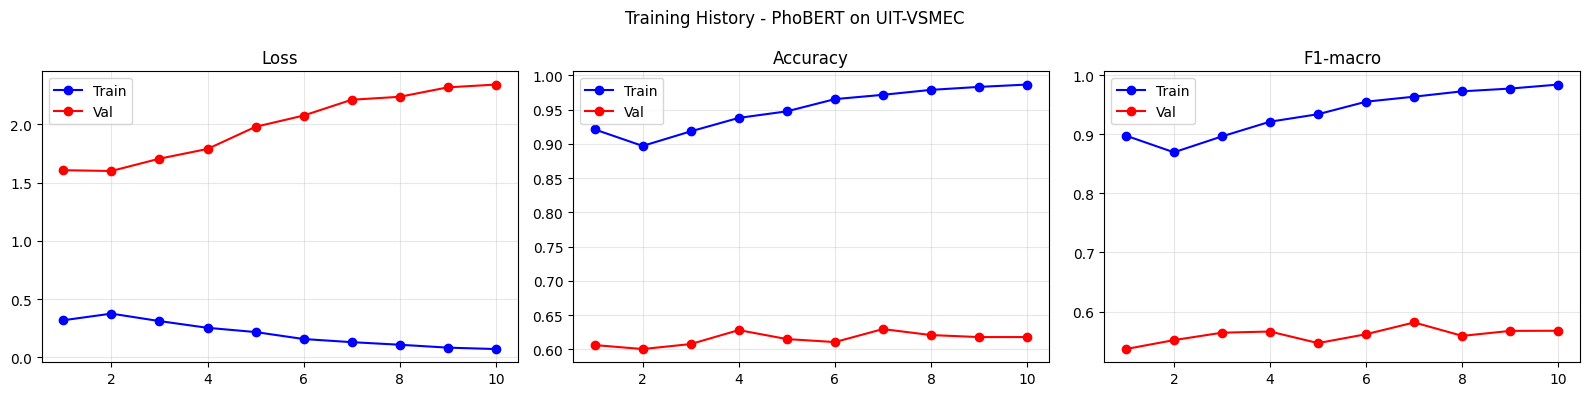

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
ep = range(1, CFG['epochs']+1)
for ax, key, title in zip(axes, ['loss','acc','f1'], ['Loss','Accuracy','F1-macro']):
    ax.plot(ep, history[f'train_{key}'], 'b-o', label='Train')
    ax.plot(ep, history[f'val_{key}'],   'r-o', label='Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training History - PhoBERT on UIT-VSMEC')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120); plt.show()

## 7. Test Set Evaluation

In [10]:
model.load_state_dict(torch.load(CFG['best_model_path'], map_location=DEVICE, weights_only=False))
test_loss, test_m = evaluate(model, test_loader, criterion, DEVICE)
print('=== TEST RESULTS ===')
for k, v in test_m.items(): print(f'  {k}: {v:.4f}')

@torch.no_grad()
def get_preds(model, loader, device):
    model.eval()
    Y, P = [], []
    for b in loader:
        logits = model(b['input_ids'].to(device), b['attention_mask'].to(device))
        P.extend(logits.argmax(dim=-1).cpu().numpy())
        Y.extend(b['labels'].numpy())
    return np.array(Y), np.array(P)

y_true, y_pred = get_preds(model, test_loader, DEVICE)
print(classification_report(y_true, y_pred, target_names=CFG['labels'], zero_division=0))

Eval:   0%|          | 0/44 [00:00<?, ?it/s]

=== TEST RESULTS ===
  accuracy: 0.6566
  f1_macro: 0.6480
  f1_weighted: 0.6594
              precision    recall  f1-score   support

   Enjoyment       0.77      0.68      0.72       193
     Sadness       0.72      0.68      0.70       116
       Anger       0.58      0.45      0.51        40
     Disgust       0.62      0.62      0.62       132
        Fear       0.78      0.67      0.72        46
    Surprise       0.71      0.65      0.68        37
       Other       0.51      0.69      0.59       129

    accuracy                           0.66       693
   macro avg       0.67      0.64      0.65       693
weighted avg       0.67      0.66      0.66       693



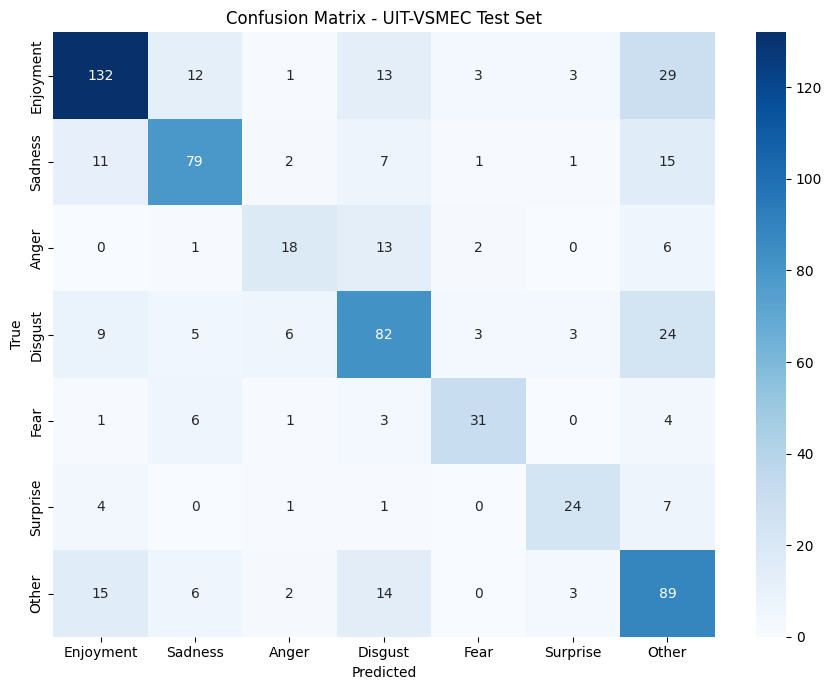

In [11]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG['labels'], yticklabels=CFG['labels'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - UIT-VSMEC Test Set')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=120); plt.show()

## 8. Inference Demo

In [12]:
def predict(text, model, tokenizer, device):
    enc = tokenizer(text, max_length=CFG['max_len'], padding='max_length',
                    truncation=True, return_tensors='pt')
    model.eval()
    with torch.no_grad():
        logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
        probs  = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    results = [{'emotion': lbl, 'prob': float(p)} for lbl, p in zip(CFG['labels'], probs)]
    results.sort(key=lambda x: x['prob'], reverse=True)
    return results

demo_texts = [
    'hôm nay mình vui lắm, đi chơi với bạn bè thật tuyệt!',
    'tức quá đi, sao mày lại làm vậy với tao???',
    'nhớ ông ấy lắm, buồn không biết làm sao...',
    'trời ơi không thể tin được, sao lại xảy ra chuyện này!',
]
for txt in demo_texts:
    res = predict(txt, model, tokenizer, DEVICE)
    top = res[0]
    print(f'Text   : {txt}')
    print(f'Emotion: {top["emotion"]} ({top["prob"]:.4f})')
    print()

Text   : hôm nay mình vui lắm, đi chơi với bạn bè thật tuyệt!
Emotion: Enjoyment (0.9968)

Text   : tức quá đi, sao mày lại làm vậy với tao???
Emotion: Anger (0.9841)

Text   : nhớ ông ấy lắm, buồn không biết làm sao...
Emotion: Sadness (0.9965)

Text   : trời ơi không thể tin được, sao lại xảy ra chuyện này!
Emotion: Surprise (0.9619)



## 9. Save Model & Push to HuggingFace Hub
Do đã push lên HuggingFace r -> người test vui lòng bỏ qua bước này (Section 9) và chạy tiếp Section 10

In [ ]:
SAVE_DIR = './saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)
model.encoder.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
torch.save(model.state_dict(), f'{SAVE_DIR}/classifier_head.pt')
with open(f'{SAVE_DIR}/emotion_config.json', 'w') as f:
    json.dump({'labels': CFG['labels'], 'num_labels': CFG['num_labels'],
               'max_len': CFG['max_len'], 'model_name': CFG['model_name'],
               'dataset': 'tridm/UIT-VSMEC'}, f, indent=2)
print('Model saved to', SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./saved_model


In [ ]:
if CFG['push_to_hub']:
    from huggingface_hub import HfApi

    # ĐIỀN TOKEN CỦA BẠN VÀO ĐÂY (Token phải có quyền WRITE)
    MY_TOKEN = 'vì lý do bảo mật cũng như đã push lên r => chỗ này sẽ ko để token của e'

    # Truyền token thẳng vào API để tránh bị kẹt token cũ
    api = HfApi(token=MY_TOKEN)

    try:
        api.create_repo(repo_id=CFG['hf_repo'], repo_type='model', exist_ok=True)
        api.upload_folder(
            folder_path=SAVE_DIR,
            repo_id=CFG['hf_repo'],
            repo_type='model'
        )
        print(f"✅ Pushed successfully to https://huggingface.co/{CFG['hf_repo']}")
    except Exception as e:
        print(f"❌ Lỗi khi upload: {e}")
else:
    print('Set CFG[push_to_hub]=True to upload to HuggingFace Hub')


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._model/classifier_head.pt:   0%|          |  150kB /  541MB            

  ...d_model/model.safetensors:   0%|          |  549kB /  540MB            

✅ Pushed successfully to https://huggingface.co/RudiChill/vismec-emotion


## 10. Gradio Interactive Demo

In [13]:
!pip install gradio -q


In [14]:
import gradio as gr

EMOJI = {'Enjoyment':'😊','Sadness':'😢','Anger':'😡','Disgust':'🤢',
         'Fear':'😨','Surprise':'😲','Other':'😐'}

def gradio_predict(text):
    if not text.strip(): return 'Please enter text.', {}
    res    = predict(text, model, tokenizer, DEVICE)
    top    = res[0]
    label  = f"{EMOJI[top['emotion']]} {top['emotion']} ({top['prob']:.2%})"
    scores = {f"{EMOJI[r['emotion']]} {r['emotion']}": float(r['prob']) for r in res}
    return label, scores

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, placeholder='Nhập câu tiếng Việt...', label='Input Text'),
    outputs=[gr.Textbox(label='Predicted Emotion'), gr.Label(label='Probabilities', num_top_classes=7)],
    title='Vietnamese Emotion Recognition - UIT-VSMEC',
    description='Fine-tuned PhoBERT-base-v2 trên dataset UIT-VSMEC (7 nhãn cảm xúc).',
    examples=[
        ['hôm nay mình vui lắm, đi chơi với bạn bè thật tuyệt!'],
        ['tức quá đi, sao mày lại làm vậy!!!'],
        ['nhớ ông ấy lắm, buồn không biết làm sao...'],
        ['trời ơi không thể tin được chuyện này!'],
    ],
    theme=gr.themes.Soft()
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://52f260511fd60fec1a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
